# Mathan Kumar Thavu Mudaliar Kanagaraj

# DSC 680 Applied Data Science

# Project: Anomaly Detection in Credit Card Transactions: Leveraging Machine Learning for Fraud Classification

# Professor: Amirfarrokh Iranitalab

# 1. Importing Libraries

In [201]:
# Importing necessary libraries for data analysis and visualization
import pandas as pd  # Import the pandas library for data manipulation and analysis, particularly with DataFrames
import matplotlib.pyplot as plt  # Import matplotlib for creating static, interactive, and animated visualizations in Python
import seaborn as sns  # Import Seaborn for enhanced data visualization based on Matplotlib, for better aesthetics and easier syntax
import numpy as np  # Import NumPy for efficient numerical operations, array manipulations, and mathematical functions
from wordcloud import WordCloud # Import the WordCloud class from the wordcloud library to create word cloud visualizations

# Importing modules for handling imbalanced datasets. SMOTE (Synthetic Minority Over-sampling Technique)
from imblearn.over_sampling import SMOTE  # Import SMOTE to address class imbalance by generating synthetic samples

# Importing modules for model training and evaluation
from sklearn.model_selection import train_test_split  # Import train_test_split to divide the dataset into training and testing subsets
from sklearn.linear_model import LogisticRegression  # Import Logistic Regression model for binary classification tasks
from sklearn.preprocessing import StandardScaler  # Import StandardScaler to standardize features by removing mean & scaling unit variance

# Importing evaluation metrics to assess model performance
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, 
                             precision_score, recall_score, f1_score)  # Import various metrics for model evaluation

# Importing ensemble methods for classification
from sklearn.ensemble import RandomForestClassifier  # Import Random Forest classifier for ensemble learning using decision trees
from sklearn.ensemble import GradientBoostingClassifier  # Import Gradient Boosting classifier for boosting learners into a strong ones

# Import necessary libraries for hyperparameter tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold

from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter
import matplotlib.patches as mpatches


import nltk  # Import the Natural Language Toolkit (NLTK) for natural language processing tasks
from nltk.corpus import stopwords  # Import stopwords from NLTK for filtering out common words that may not contribute to text analysis
import string  # Import string for common string operations and manipulation
from sklearn.preprocessing import LabelEncoder  # Import LabelEncoder to convert categorical labels into numerical format for model training
from xgboost import XGBClassifier  # Import XGBClassifier, a gradient boosting algorithm for classification tasks
from bayes_opt import BayesianOptimization # Import BayesianOptimization for efficient hyperparameter tuning using Bayesian optimization

# 2. Data Loading

In [74]:
# Loading the CSV file
df = pd.read_csv('credit_card_fraud.csv')

# Displaying first few rows
print("\n" + "=" * 60)
print("Sample from Dataset")
print("=" * 60)
print(df.head())


Sample from Dataset
   transaction_id  amount  transaction_hour merchant_category  \
0               1   84.47                22       Electronics   
1               2  541.82                 3            Travel   
2               3  237.01                17           Grocery   
3               4  164.33                 4           Grocery   
4               5   30.53                15              Food   

   foreign_transaction  location_mismatch  device_trust_score  \
0                    0                  0                  66   
1                    1                  0                  87   
2                    0                  0                  49   
3                    0                  1                  72   
4                    0                  0                  79   

   velocity_last_24h  cardholder_age  is_fraud  
0                  3              40         0  
1                  1              64         0  
2                  1              61         0  
3

# 3. Data Discovery

In [52]:
# Validating the shape of the dataset
print("\n" + "=" * 60)
print(f"DataFrame shape: {df.shape}")
print("=" * 60)


DataFrame shape: (10000, 10)


In [54]:
# Understanding the Features available in the dataset
print("\n" + "=" * 60)
print(f"Features in the Dataset")
print("=" * 60)
df.columns


Features in the Dataset


Index(['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='object')

In [56]:
# Checking data types
print("\n" + "=" * 60)
print("Data Types of Features")
print("=" * 60)
print(df.dtypes)


Data Types of Features
transaction_id           int64
amount                 float64
transaction_hour         int64
merchant_category       object
foreign_transaction      int64
location_mismatch        int64
device_trust_score       int64
velocity_last_24h        int64
cardholder_age           int64
is_fraud                 int64
dtype: object


In [58]:
# Understanding basic statistics for numerical columns
print("\n" + "=" * 60)
print("Statistics")
print("=" * 60)
print(df.describe())


Statistics
       transaction_id        amount  transaction_hour  foreign_transaction  \
count     10000.00000  10000.000000      10000.000000         10000.000000   
mean       5000.50000    175.949849         11.593300             0.097800   
std        2886.89568    175.392827          6.922708             0.297059   
min           1.00000      0.000000          0.000000             0.000000   
25%        2500.75000     50.905000          6.000000             0.000000   
50%        5000.50000    122.095000         12.000000             0.000000   
75%        7500.25000    242.480000         18.000000             0.000000   
max       10000.00000   1471.040000         23.000000             1.000000   

       location_mismatch  device_trust_score  velocity_last_24h  \
count       10000.000000        10000.000000       10000.000000   
mean            0.085700           61.798900           2.008900   
std             0.279935           21.487053           1.432559   
min             0

In [60]:
# Checking for duplicate rows
duplicate_rows = df[df.duplicated()]
print("\n" + "=" * 60)
print("Duplicate Rows Details")
print("=" * 60)
duplicate_rows.shape


Duplicate Rows Details


(0, 10)

In [62]:
# Check for missing values
print("\n" + "=" * 60)
print("Missing Values in Features")
print("=" * 60)
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Feature': missing.index,
    'Missing Count': missing.values,
    'Missing Percentage': missing_percent.values
})
print(missing_df[missing_df['Missing Count'] > 0].to_string(index=False))

print(f"\n\nMissing values at each feature:\n\n{df.isnull().sum()}")



Missing Values in Features
Empty DataFrame
Columns: [Feature, Missing Count, Missing Percentage]
Index: []


Missing values at each feature:

transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64


# 4. Data Preprocessing

In [64]:
# Creating a copy of dataframe for Preprocessing step
df_cleanup = df.copy()

# Validaing the new dataframe
df_cleanup.shape

(10000, 10)

## 4.1. Drop Irrelevant Features

In [76]:
# Dropping transaction_id from df_cleanup
df_cleanup = df.drop('transaction_id', axis=1)

# Verifying the column has been dropped
print(df_cleanup.columns.tolist())
print(df_cleanup.shape)

['amount', 'transaction_hour', 'merchant_category', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age', 'is_fraud']
(10000, 9)


In [68]:
df_cleanup.head()

,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,84.47,22,Electronics,0,0,66,3,40,0
1,541.82,3,Travel,1,0,87,1,64,0
2,237.01,17,Grocery,0,0,49,1,61,0
3,164.33,4,Grocery,0,1,72,3,34,0
4,30.53,15,Food,0,0,79,0,44,0


## 4.2. Encoding

In [78]:
# Displaying unique values in merchant_category
print(df_cleanup['merchant_category'].unique())
print(f'Total unique values: {df_cleanup["merchant_category"].nunique()}')

['Electronics' 'Travel' 'Grocery' 'Food' 'Clothing']
Total unique values: 5


In [80]:
# Applying One-Hot Encoding for all 5 categories without removing the original column
ohe_cols = pd.get_dummies(df_cleanup['merchant_category'], prefix='merchant_category', drop_first=False)
df_cleanup = pd.concat([df_cleanup, ohe_cols], axis=1)

# Validating the result
print(df_cleanup.columns.tolist())

['amount', 'transaction_hour', 'merchant_category', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age', 'is_fraud', 'merchant_category_Clothing', 'merchant_category_Electronics', 'merchant_category_Food', 'merchant_category_Grocery', 'merchant_category_Travel']


## 4.3. Feature Engineering

In [86]:
# Displaying unique values in transaction_hour in ascending order
print(sorted(df_cleanup['transaction_hour'].unique()))
print(f'Total unique values: {df_cleanup["transaction_hour"].nunique()}')

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
Total unique values: 24


In [88]:
# Displaying unique values in cardholder_age in ascending order
print(sorted(df_cleanup['cardholder_age'].unique()))
print(f'Total unique values: {df_cleanup["cardholder_age"].nunique()}')

[18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69]
Total unique values: 52


In [92]:
# Creating transaction_hour_risk_indicator feature
df_cleanup['transaction_hour_risk_indicator'] = df_cleanup['transaction_hour'].apply(
    lambda x: 1 if 1 <= x <= 5 else 0
)

# Validating the result
print(df_cleanup[['transaction_hour', 'transaction_hour_risk_indicator']].value_counts().sort_index())

transaction_hour  transaction_hour_risk_indicator
0                 0                                  417
1                 1                                  425
2                 1                                  385
3                 1                                  425
4                 1                                  384
5                 1                                  419
6                 0                                  413
7                 0                                  425
8                 0                                  424
9                 0                                  426
10                0                                  358
11                0                                  385
12                0                                  417
13                0                                  420
14                0                                  458
15                0                                  432
16                0                   

In [94]:
# Creating cardholder_senior_citizen feature
df_cleanup['cardholder_senior_citizen'] = df_cleanup['cardholder_age'].apply(
    lambda x: 1 if x >= 65 else 0
)

# Validating the result
print(df_cleanup[['cardholder_age', 'cardholder_senior_citizen']].value_counts().sort_index())

cardholder_age  cardholder_senior_citizen
18              0                            193
19              0                            196
20              0                            170
21              0                            195
22              0                            209
23              0                            190
24              0                            184
25              0                            199
26              0                            171
27              0                            186
28              0                            207
29              0                            215
30              0                            187
31              0                            203
32              0                            199
33              0                            190
34              0                            194
35              0                            185
36              0                            193
37              0          

## 4.4. Feature Scaling

In [99]:
# Initializing the StandardScaler to normalize data to zero mean and unit variance [6, 8]
scaler = StandardScaler()
# Define the list of numerical feature columns that require scaling to ensure 
# they are on the same magnitude for machine learning algorithms [4, 6]
scale_cols = ['amount', 'device_trust_score', 'cardholder_age', 'velocity_last_24h']

# Creating new scaled columns while retaining the original columns
scaled_col_names = [col + '_scaled' for col in scale_cols]
df_cleanup[scaled_col_names] = scaler.fit_transform(df_cleanup[scale_cols])

# Validating the result
print(df_cleanup[scale_cols + scaled_col_names].head())

   amount  device_trust_score  cardholder_age  velocity_last_24h  \
0   84.47                  66              40                  3   
1  541.82                  87              64                  1   
2  237.01                  49              61                  1   
3  164.33                  72              34                  3   
4   30.53                  79              44                  0   

   amount_scaled  device_trust_score_scaled  cardholder_age_scaled  \
0      -0.521597                   0.195528              -0.231580   
1       2.086108                   1.172909               1.370727   
2       0.348151                  -0.595686               1.170439   
3      -0.066254                   0.474779              -0.632157   
4      -0.829151                   0.800573               0.035471   

   velocity_last_24h_scaled  
0                  0.691873  
1                 -0.704299  
2                 -0.704299  
3                  0.691873  
4                 -1

## 4.5. Class Balancing

In [102]:
# Creating a dataframe for Class Balancing
df_bal = df_cleanup.copy()

df_bal.shape

(10000, 20)

In [104]:
df_bal.columns

Index(['amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud',
       'merchant_category_Clothing', 'merchant_category_Electronics',
       'merchant_category_Food', 'merchant_category_Grocery',
       'merchant_category_Travel', 'transaction_hour_risk_indicator',
       'cardholder_senior_citizen', 'amount_scaled',
       'device_trust_score_scaled', 'cardholder_age_scaled',
       'velocity_last_24h_scaled'],
      dtype='object')

In [110]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Dropping the original text column before balancing
X_bal = df_bal.drop(['is_fraud', 'merchant_category'], axis=1)
y_bal = df_bal['is_fraud']

# Displaying class distribution before balancing
print(f'Class distribution before SMOTE:')
print(Counter(y_bal))

# Applying SMOTE
smote = SMOTE(random_state=42)
X_bal_resampled, y_bal_resampled = smote.fit_resample(X_bal, y_bal)

# Displaying class distribution after balancing
print(f'\nClass distribution after SMOTE:')
print(Counter(y_bal_resampled))

# Reconstructing the balanced dataframe
df_bal_resampled = pd.DataFrame(X_bal_resampled, columns=X_bal.columns)
df_bal_resampled['is_fraud'] = y_bal_resampled

print(f'\nShape before SMOTE: {df_bal.shape}')
print(f'Shape after SMOTE: {df_bal_resampled.shape}')

Class distribution before SMOTE:
Counter({0: 9849, 1: 151})

Class distribution after SMOTE:
Counter({0: 9849, 1: 9849})

Shape before SMOTE: (10000, 20)
Shape after SMOTE: (19698, 19)


In [114]:
# Frequency of is_fraud
print('Frequency Count:')
print(df_bal_resampled['is_fraud'].value_counts())

print('\nFrequency Percentage:')
print(df_bal_resampled['is_fraud'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Frequency Count:
is_fraud
0    9849
1    9849
Name: count, dtype: int64

Frequency Percentage:
is_fraud
0    50.0%
1    50.0%
Name: proportion, dtype: object


In [118]:
df_cleanup.columns

Index(['amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud',
       'merchant_category_Clothing', 'merchant_category_Electronics',
       'merchant_category_Food', 'merchant_category_Grocery',
       'merchant_category_Travel', 'transaction_hour_risk_indicator',
       'cardholder_senior_citizen', 'amount_scaled',
       'device_trust_score_scaled', 'cardholder_age_scaled',
       'velocity_last_24h_scaled'],
      dtype='object')

# 5. Exploratory Data Analysis (EDA)

## 5.1. Fraud vs Non-Fraud Class Distribution

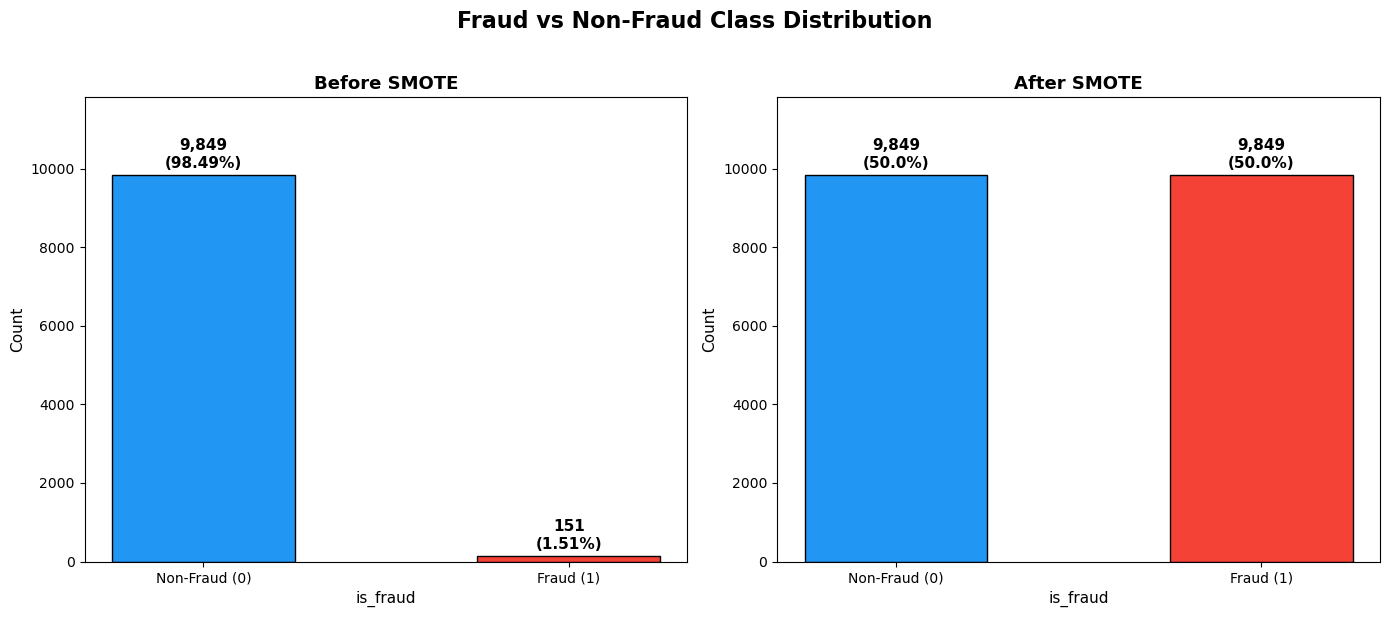

In [124]:
# Defining figure dimensions with 1 row and 2 columns of subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Setting the main title for the entire figure
fig.suptitle('Fraud vs Non-Fraud Class Distribution', fontsize=16, fontweight='bold', y=1.02)

# Class Distribution Before SMOTE

# Counting the number of occurrences of each class (0 and 1) before SMOTE
before_counts = df_cleanup['is_fraud'].value_counts()

# Calculating the percentage of each class before SMOTE
before_pct = df_cleanup['is_fraud'].value_counts(normalize=True).mul(100).round(2)

# Defining bar labels and colors for Non-Fraud (blue) and Fraud (red)
labels = ['Non-Fraud (0)', 'Fraud (1)']
colors = ['#2196F3', '#F44336']

# Plotting the bar chart for class distribution before SMOTE
bars1 = axes[0].bar(labels, before_counts.values, color=colors, edgecolor='black', width=0.5)

# Defining the title, axis labels, and y-axis limit for the before SMOTE chart
axes[0].set_title('Before SMOTE', fontsize=13, fontweight='bold')
axes[0].set_xlabel('is_fraud', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)

# Setting y-axis limit to 120% of the maximum bar height to leave room for annotations
axes[0].set_ylim(0, max(before_counts.values) * 1.2)

# Annotating each bar with its count and percentage for the before SMOTE chart
for bar, count, pct in zip(bars1, before_counts.values, before_pct.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,  # Horizontal center of the bar
                 bar.get_height() + 100,               # Slightly above the bar
                 f'{count:,}\n({pct}%)',               # Displaying count and percentage
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# Class Distribution After SMOTE

# Counting the number of occurrences of each class (0 and 1) after SMOTE
after_counts = df_bal_resampled['is_fraud'].value_counts()

# Calculating the percentage of each class after SMOTE
after_pct = df_bal_resampled['is_fraud'].value_counts(normalize=True).mul(100).round(2)

# Plotting the bar chart for class distribution after SMOTE
bars2 = axes[1].bar(labels, after_counts.values, color=colors, edgecolor='black', width=0.5)

# Defining the title, axis labels, and y-axis limit for the after SMOTE chart
axes[1].set_title('After SMOTE', fontsize=13, fontweight='bold')
axes[1].set_xlabel('is_fraud', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)

# Defining y-axis limit to 120% of the maximum bar height to leave room for annotations
axes[1].set_ylim(0, max(after_counts.values) * 1.2)

# Annotating each bar with its count and percentage for the after SMOTE chart
for bar, count, pct in zip(bars2, after_counts.values, after_pct.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2,  # Horizontal center of the bar
                 bar.get_height() + 100,               # Slightly above the bar
                 f'{count:,}\n({pct}%)',               # Displaying count and percentage
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# Adjusting layout to prevent overlapping elements
plt.tight_layout()

# Displaying the final plots
plt.show()

## 5.2. Transaction Amount Distribution by Fraud Status 

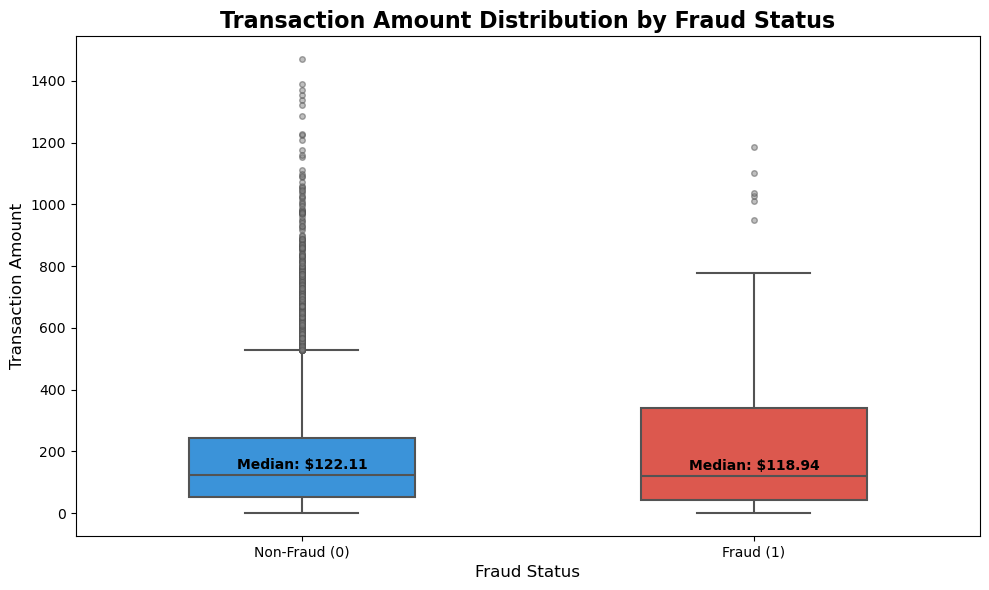

In [130]:
# Defining figure dimensions
fig, ax = plt.subplots(figsize=(10, 6))

# Setting the main title for the figure
ax.set_title('Transaction Amount Distribution by Fraud Status', fontsize=16, fontweight='bold')

# Creating a mapped label column for better readability on the chart
df_cleanup['fraud_label'] = df_cleanup['is_fraud'].map({0: 'Non-Fraud (0)', 1: 'Fraud (1)'})

# Defining colors for Non-Fraud (blue) and Fraud (red)
colors = {'Non-Fraud (0)': '#2196F3', 'Fraud (1)': '#F44336'}

# Plotting the side-by-side box plot with hue assigned to fix FutureWarning
sns.boxplot(
    data=df_cleanup,
    x='fraud_label',
    y='amount',
    hue='fraud_label',        # Assigning hue to x variable to fix FutureWarning
    palette=colors,
    legend=False,             # Hiding legend since hue mirrors x
    width=0.5,
    linewidth=1.5,
    flierprops=dict(marker='o', markerfacecolor='grey', markersize=4, alpha=0.5),
    ax=ax
)

# Setting axis labels
ax.set_xlabel('Fraud Status', fontsize=12)
ax.set_ylabel('Transaction Amount', fontsize=12)

# Adding median annotations on top of each box
for i, label in enumerate(['Non-Fraud (0)', 'Fraud (1)']):
    median_val = df_cleanup[df_cleanup['fraud_label'] == label]['amount'].median()
    ax.text(i, median_val + 10,
            f'Median: ${median_val:,.2f}',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='black')

# Adjusting layout to prevent overlapping elements
plt.tight_layout()

# Displaying the final chart
plt.show()

# Dropping the temporary fraud_label column after plotting
df_cleanup = df_cleanup.drop('fraud_label', axis=1)

## 5.3. Fraud Rate by Transaction Hour

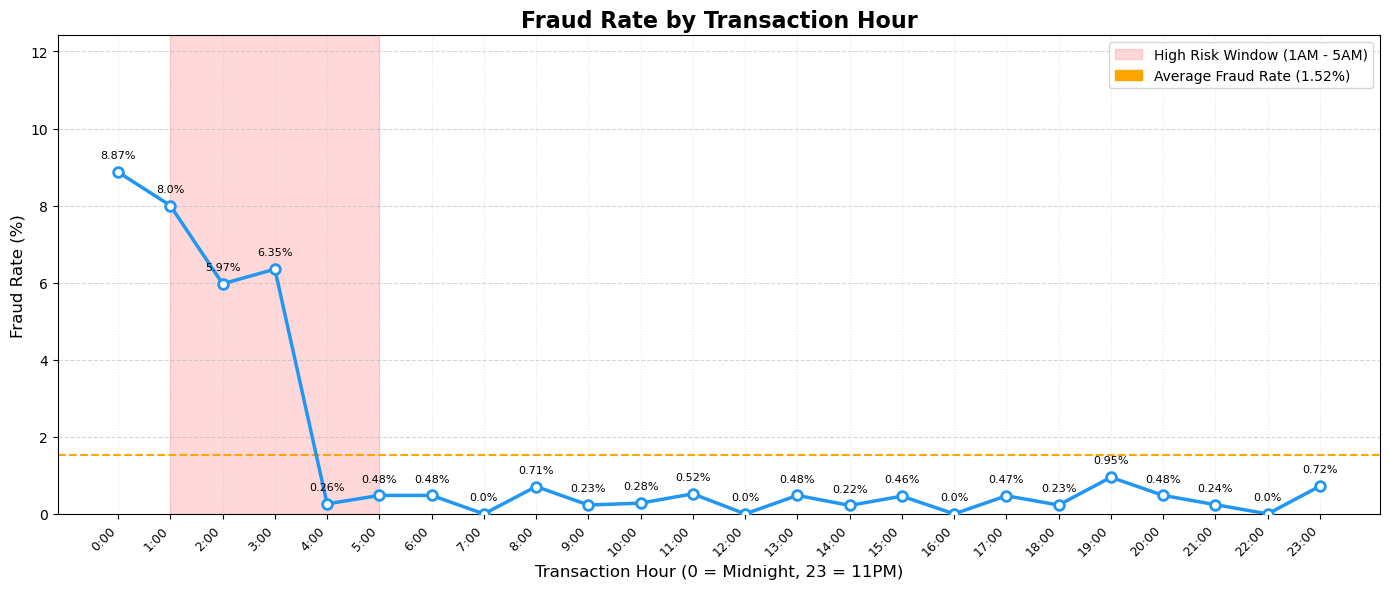

In [138]:
# Calculating fraud rate per transaction hour
fraud_by_hour = df_cleanup.groupby('transaction_hour')['is_fraud'].mean().mul(100).round(2).reset_index()
fraud_by_hour.columns = ['transaction_hour', 'fraud_rate']

# Defining figure dimensions
fig, ax = plt.subplots(figsize=(14, 6))

# Defining the main title for the figure
ax.set_title('Fraud Rate by Transaction Hour', fontsize=16, fontweight='bold')

# Highlighting the high risk window (1 AM to 5 AM) in the background
ax.axvspan(1, 5, alpha=0.15, color='red', label='High Risk Window (1AM - 5AM)')

# Plotting the line chart
ax.plot(
    fraud_by_hour['transaction_hour'],
    fraud_by_hour['fraud_rate'],
    color='#2196F3',
    linewidth=2.5,
    marker='o',
    markersize=7,
    markerfacecolor='white',
    markeredgecolor='#2196F3',
    markeredgewidth=2,
    zorder=3
)

# Annotating each data point with its fraud rate value
for _, row in fraud_by_hour.iterrows():
    ax.annotate(
        f"{row['fraud_rate']}%",
        xy=(row['transaction_hour'], row['fraud_rate']),
        xytext=(0, 10),
        textcoords='offset points',
        ha='center',
        fontsize=8,
        color='black'
    )

# Adding a horizontal dashed line for the overall average fraud rate
avg_fraud_rate = fraud_by_hour['fraud_rate'].mean()
ax.axhline(
    y=avg_fraud_rate,
    color='orange',
    linestyle='--',
    linewidth=1.5,
    label=f'Average Fraud Rate ({avg_fraud_rate:.2f}%)'
)

# Defining axis labels
ax.set_xlabel('Transaction Hour (0 = Midnight, 23 = 11PM)', fontsize=12)
ax.set_ylabel('Fraud Rate (%)', fontsize=12)

# Defining x-axis ticks to show all 24 hours
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h}:00' for h in range(0, 24)], rotation=45, ha='right', fontsize=9)

# Defining y-axis limit to give space for annotations
ax.set_ylim(0, fraud_by_hour['fraud_rate'].max() * 1.4)

# Defining grid lines for readability
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.grid(axis='x', linestyle=':', alpha=0.3)

# Defining legend
high_risk_patch = mpatches.Patch(color='red', alpha=0.15, label='High Risk Window (1AM - 5AM)')
avg_line = mpatches.Patch(color='orange', label=f'Average Fraud Rate ({avg_fraud_rate:.2f}%)')
ax.legend(handles=[high_risk_patch, avg_line], fontsize=10, loc='upper right')

# Adjusting layout to prevent overlapping elements
plt.tight_layout()

# Displaying the final plot
plt.show()

## 5.4. Fraud Rate by Merchant Category

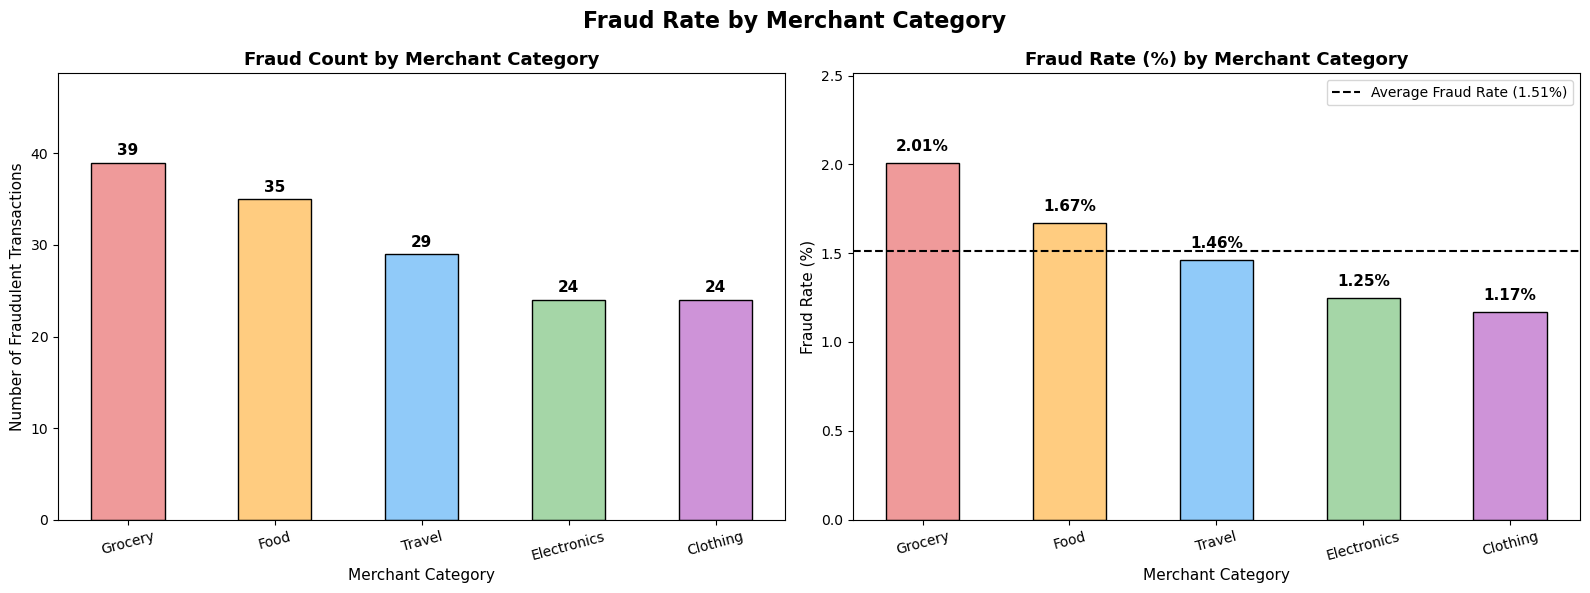

In [145]:
# Calculating fraud count and fraud rate per merchant category
fraud_by_category = df_cleanup.groupby('merchant_category').agg(
    total_transactions=('is_fraud', 'count'),
    fraud_count=('is_fraud', 'sum')
).reset_index()

# Calculating fraud rate percentage
fraud_by_category['fraud_rate'] = (
    fraud_by_category['fraud_count'] / fraud_by_category['total_transactions']
).mul(100).round(2)

# Sorting by fraud rate in descending order
fraud_by_category = fraud_by_category.sort_values('fraud_rate', ascending=False).reset_index(drop=True)

# Defining figure dimensions with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Fraud Rate by Merchant Category', fontsize=16, fontweight='bold')

# Defining colors for each merchant category
colors = ['#EF9A9A', '#FFCC80', '#90CAF9', '#A5D6A7', '#CE93D8']

# Fraud Count per Merchant Category

# Plotting the bar chart for fraud count
bars1 = axes[0].bar(
    fraud_by_category['merchant_category'],
    fraud_by_category['fraud_count'],
    color=colors,
    edgecolor='black',
    width=0.5
)

# Defining title and axis labels for the left chart
axes[0].set_title('Fraud Count by Merchant Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Merchant Category', fontsize=11)
axes[0].set_ylabel('Number of Fraudulent Transactions', fontsize=11)
axes[0].set_ylim(0, fraud_by_category['fraud_count'].max() * 1.25)

# Rotating x-axis labels for readability
axes[0].tick_params(axis='x', rotation=15)

# Annotating each bar with its fraud count
for bar, count in zip(bars1, fraud_by_category['fraud_count']):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{count:,}',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

# Fraud Rate per Merchant Category

# Plotting the bar chart for fraud rate
bars2 = axes[1].bar(
    fraud_by_category['merchant_category'],
    fraud_by_category['fraud_rate'],
    color=colors,
    edgecolor='black',
    width=0.5
)

# Defining title and axis labels for the right chart
axes[1].set_title('Fraud Rate (%) by Merchant Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Merchant Category', fontsize=11)
axes[1].set_ylabel('Fraud Rate (%)', fontsize=11)
axes[1].set_ylim(0, fraud_by_category['fraud_rate'].max() * 1.25)

# Rotating x-axis labels for readability
axes[1].tick_params(axis='x', rotation=15)

# Adding a horizontal dashed line for the overall average fraud rate
avg_fraud_rate = fraud_by_category['fraud_rate'].mean()
axes[1].axhline(
    y=avg_fraud_rate,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label=f'Average Fraud Rate ({avg_fraud_rate:.2f}%)'
)

# Annotating each bar with its fraud rate percentage
for bar, rate in zip(bars2, fraud_by_category['fraud_rate']):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f'{rate}%',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

# Adding legend for the average fraud rate line
axes[1].legend(fontsize=10, loc='upper right')

# Adjusting layout to prevent overlapping elements
plt.tight_layout()

# Displaying the final plots
plt.show()

## 5.5. Correlation Heatmap of Numerical Features

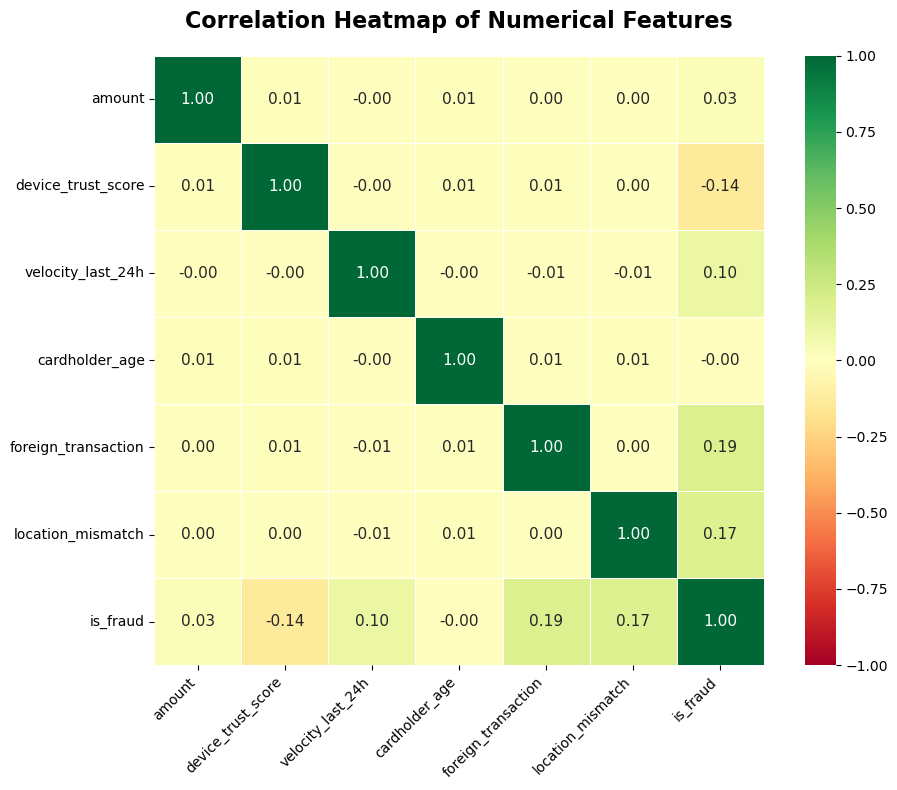

In [159]:
# Choosing relevant numerical features and target variable
corr_cols = [
    'amount', 'device_trust_score', 'velocity_last_24h',
    'cardholder_age', 'foreign_transaction', 'location_mismatch',
    'is_fraud'
]

# Computing the correlation matrix
corr_matrix = df_cleanup[corr_cols].corr()

# Defining figure dimensions
fig, ax = plt.subplots(figsize=(10, 8))

# Defining the main title for the figure
ax.set_title('Correlation Heatmap of Numerical Features', fontsize=16, fontweight='bold', pad=20)

# Plotting the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,                 # Displaying correlation values inside each cell
    fmt='.2f',                  # Formatting correlation values to 2 decimal places
    cmap='RdYlGn',              # Red for negative, Yellow for neutral, Green for positive
    center=0,                   # Centering the colormap at 0
    vmin=-1,                    # Minimum correlation value
    vmax=1,                     # Maximum correlation value
    linewidths=0.5,             # Adding gridlines between cells
    linecolor='white',          # Setting gridline color to white
    annot_kws={'size': 11},     # Setting annotation font size
    square=True,                # Making each cell square shaped
    ax=ax
)

# Rotating x-axis labels for readability
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right',
    fontsize=10
)

# Rotating y-axis labels for readability
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=10
)


# Adjusting layout to prevent overlapping elements
plt.tight_layout()

# Displaying the final chart
plt.show()

## 5.6. Device Trust Score Distribution by Fraud Status

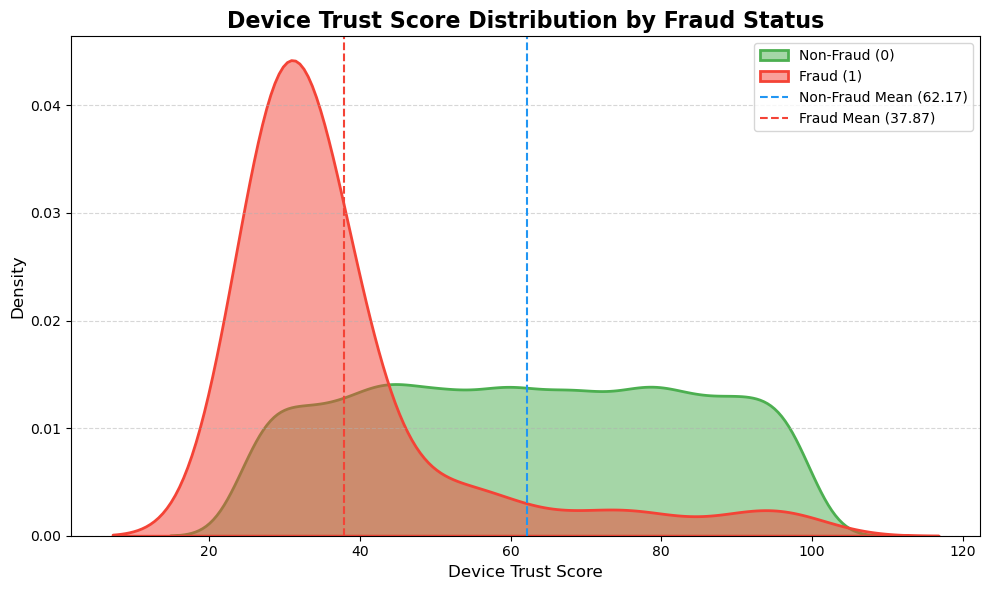

In [153]:
import matplotlib.pyplot as plt
import seaborn as sns

# Defining figure dimensions
fig, ax = plt.subplots(figsize=(10, 6))

# Setting the main title for the figure
ax.set_title('Device Trust Score Distribution by Fraud Status', fontsize=16, fontweight='bold')

# Separating fraud and non-fraud data
non_fraud = df_cleanup[df_cleanup['is_fraud'] == 0]['device_trust_score']
fraud = df_cleanup[df_cleanup['is_fraud'] == 1]['device_trust_score']

# Defining colors for Non-Fraud (green) and Fraud (red)
color_non_fraud = '#4CAF50'
color_fraud = '#F44336'

# Plotting KDE for Non-Fraud
sns.kdeplot(
    non_fraud,
    ax=ax,
    color=color_non_fraud,
    fill=True,
    alpha=0.5,
    linewidth=2,
    label='Non-Fraud (0)'
)

# Plotting KDE for Fraud
sns.kdeplot(
    fraud,
    ax=ax,
    color=color_fraud,
    fill=True,
    alpha=0.5,
    linewidth=2,
    label='Fraud (1)'
)

# Adding vertical dashed lines for mean of each class
ax.axvline(
    non_fraud.mean(),
    color='#2196F3',
    linestyle='--',
    linewidth=1.5,
    label=f'Non-Fraud Mean ({non_fraud.mean():.2f})'
)
ax.axvline(
    fraud.mean(),
    color='#F44336',
    linestyle='--',
    linewidth=1.5,
    label=f'Fraud Mean ({fraud.mean():.2f})'
)

# Setting axis labels
ax.set_xlabel('Device Trust Score', fontsize=12)
ax.set_ylabel('Density', fontsize=12)

# Adding grid lines for readability
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Adding legend
ax.legend(fontsize=10)

# Adjusting layout to prevent overlapping elements
plt.tight_layout()

# Displaying the final chart
plt.show()

## 5.7. Fraud Rate by Foreign Transaction and Location Mismatch

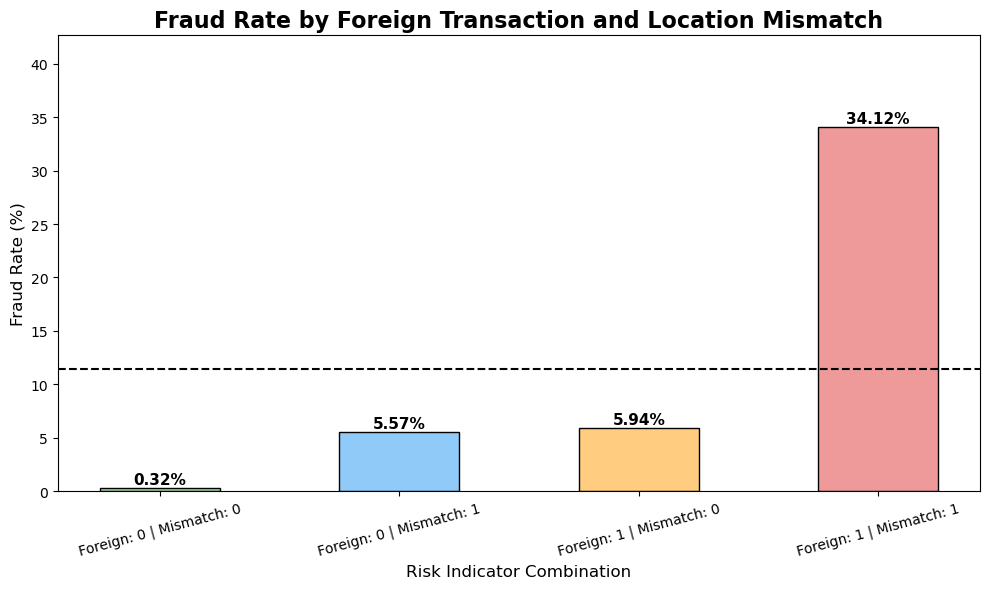

In [166]:
# Calculating fraud rate for each combination of foreign_transaction and location_mismatch
fraud_by_risk = df_cleanup.groupby(['foreign_transaction', 'location_mismatch']).agg(
    total_transactions=('is_fraud', 'count'),
    fraud_count=('is_fraud', 'sum')
).reset_index()

# Calculating fraud rate percentage
fraud_by_risk['fraud_rate'] = (
    fraud_by_risk['fraud_count'] / fraud_by_risk['total_transactions']
).mul(100).round(2)

# Creating readable labels for each combination
fraud_by_risk['combination'] = fraud_by_risk.apply(
    lambda row: f"Foreign: {int(row['foreign_transaction'])} | Mismatch: {int(row['location_mismatch'])}",
    axis=1
)

# Defining figure dimensions
fig, ax = plt.subplots(figsize=(10, 6))

# Setting the main title for the figure
ax.set_title('Fraud Rate by Foreign Transaction and Location Mismatch',
             fontsize=16, fontweight='bold')

# Defining soft colors for the 4 combinations
colors = ['#A5D6A7', '#90CAF9', '#FFCC80', '#EF9A9A']

# Plotting the bar chart for fraud rate
bars = ax.bar(
    fraud_by_risk['combination'],
    fraud_by_risk['fraud_rate'],
    color=colors,
    edgecolor='black',
    width=0.5
)

# Setting axis labels
ax.set_xlabel('Risk Indicator Combination', fontsize=12)
ax.set_ylabel('Fraud Rate (%)', fontsize=12)
ax.set_ylim(0, fraud_by_risk['fraud_rate'].max() * 1.25)

# Rotating x-axis labels for readability
ax.tick_params(axis='x', rotation=15)

# Adding a horizontal dashed line for the overall average fraud rate
avg_fraud_rate = fraud_by_risk['fraud_rate'].mean()
ax.axhline(
    y=avg_fraud_rate,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label=f'Average Fraud Rate ({avg_fraud_rate:.2f}%)'
)

# Annotating each bar with its fraud rate percentage
for bar, rate in zip(bars, fraud_by_risk['fraud_rate']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f'{rate}%',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

# Adjusting layout to prevent overlapping elements
plt.tight_layout()

# Displaying the final chart
plt.show()

## 5.8. Cardholder Age Distribution by Fraud Status

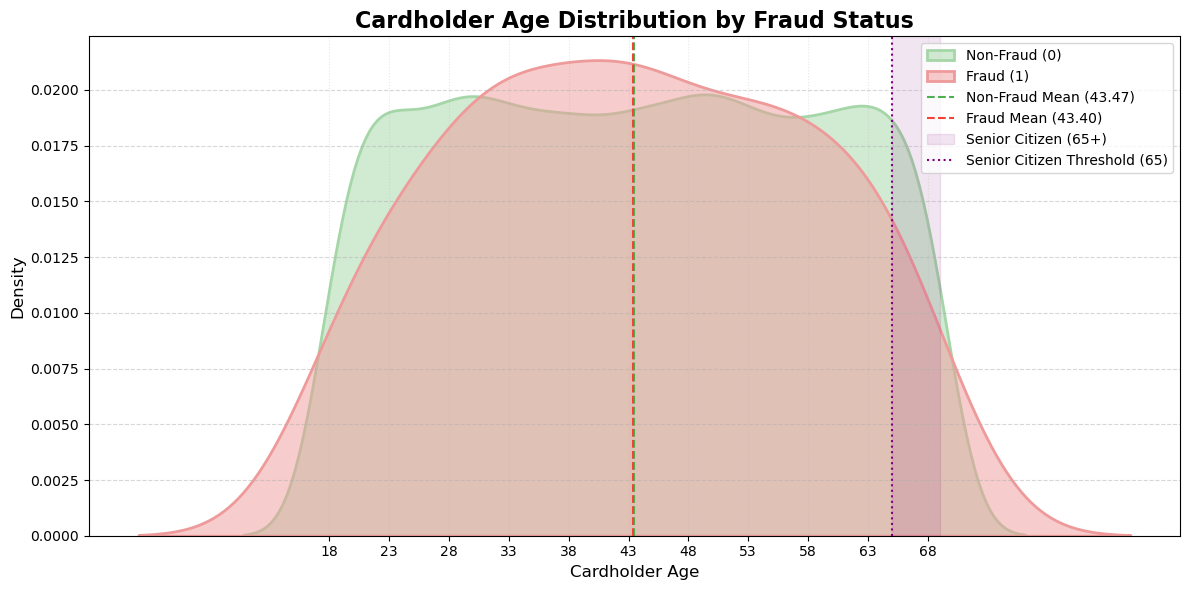

In [168]:
# Defining figure dimensions
fig, ax = plt.subplots(figsize=(12, 6))

# Setting the main title for the figure
ax.set_title('Cardholder Age Distribution by Fraud Status', fontsize=16, fontweight='bold')

# Separating fraud and non-fraud data
non_fraud = df_cleanup[df_cleanup['is_fraud'] == 0]['cardholder_age']
fraud = df_cleanup[df_cleanup['is_fraud'] == 1]['cardholder_age']

# Defining colors for Non-Fraud (green) and Fraud (red)
color_non_fraud = '#A5D6A7'
color_fraud = '#EF9A9A'

# Plotting KDE for Non-Fraud
sns.kdeplot(
    non_fraud,
    ax=ax,
    color=color_non_fraud,
    fill=True,
    alpha=0.5,
    linewidth=2,
    label='Non-Fraud (0)'
)

# Plotting KDE for Fraud
sns.kdeplot(
    fraud,
    ax=ax,
    color=color_fraud,
    fill=True,
    alpha=0.5,
    linewidth=2,
    label='Fraud (1)'
)

# Adding vertical dashed lines for mean of each class
ax.axvline(
    non_fraud.mean(),
    color='#4CAF50',
    linestyle='--',
    linewidth=1.5,
    label=f'Non-Fraud Mean ({non_fraud.mean():.2f})'
)
ax.axvline(
    fraud.mean(),
    color='#F44336',
    linestyle='--',
    linewidth=1.5,
    label=f'Fraud Mean ({fraud.mean():.2f})'
)

# Adding a shaded region to highlight the senior citizen threshold (65+)
ax.axvspan(
    65, df_cleanup['cardholder_age'].max(),
    alpha=0.1,
    color='purple',
    label='Senior Citizen (65+)'
)

# Adding a vertical line to mark the senior citizen threshold
ax.axvline(
    65,
    color='purple',
    linestyle=':',
    linewidth=1.5,
    label='Senior Citizen Threshold (65)'
)

# Setting axis labels
ax.set_xlabel('Cardholder Age', fontsize=12)
ax.set_ylabel('Density', fontsize=12)

# Setting x-axis ticks for better readability
ax.set_xticks(range(
    df_cleanup['cardholder_age'].min(),
    df_cleanup['cardholder_age'].max() + 1, 5)
)

# Adding grid lines for readability
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.grid(axis='x', linestyle=':', alpha=0.3)

# Adding legend
ax.legend(fontsize=10, loc='upper right')

# Adjusting layout to prevent overlapping elements
plt.tight_layout()

# Displaying the final chart
plt.show()

## 5.9. Fraud Cluster - Transaction Amount vs Device Trust Score 

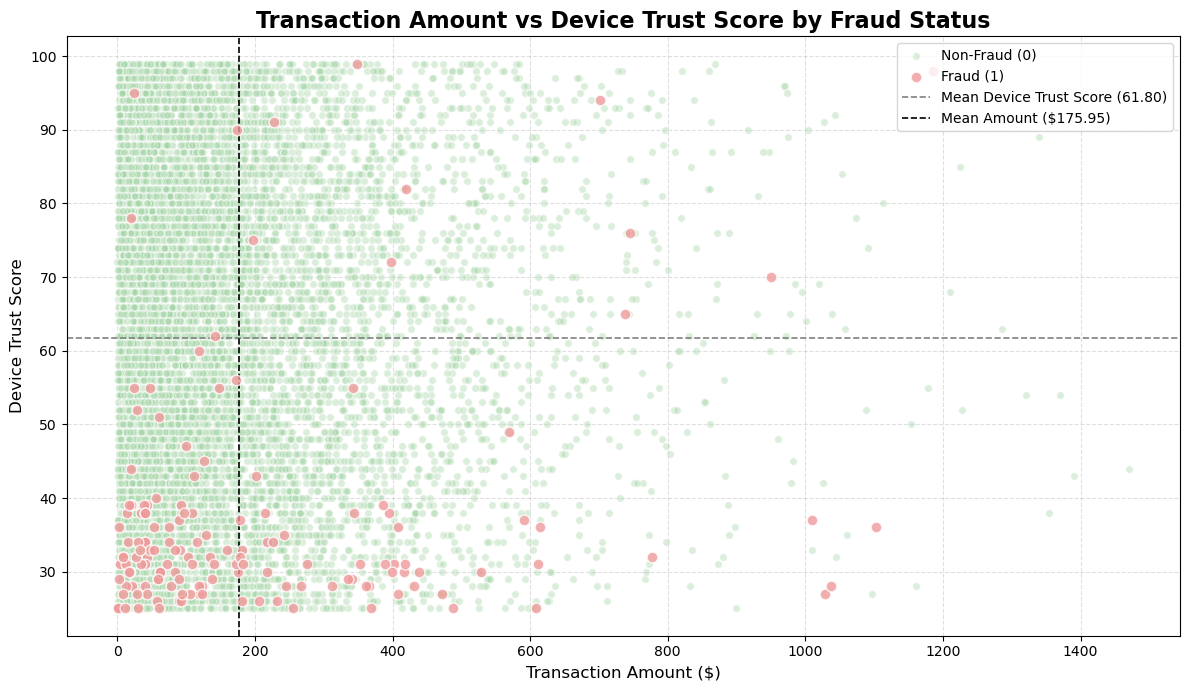

In [171]:
# Defining figure dimensions
fig, ax = plt.subplots(figsize=(12, 7))

# Setting the main title for the figure
ax.set_title('Transaction Amount vs Device Trust Score by Fraud Status',
             fontsize=16, fontweight='bold')

# Separating fraud and non-fraud data
non_fraud = df_cleanup[df_cleanup['is_fraud'] == 0]
fraud = df_cleanup[df_cleanup['is_fraud'] == 1]

# Plotting Non-Fraud scatter points
ax.scatter(
    non_fraud['amount'],
    non_fraud['device_trust_score'],
    color='#A5D6A7',
    edgecolor='white',
    alpha=0.4,
    s=30,
    label='Non-Fraud (0)',
    zorder=2
)

# Plotting Fraud scatter points on top
ax.scatter(
    fraud['amount'],
    fraud['device_trust_score'],
    color='#EF9A9A',
    edgecolor='white',
    alpha=0.8,
    s=60,
    label='Fraud (1)',
    zorder=3
)

# Adding horizontal dashed line for mean device trust score
ax.axhline(
    df_cleanup['device_trust_score'].mean(),
    color='grey',
    linestyle='--',
    linewidth=1.2,
    label=f'Mean Device Trust Score ({df_cleanup["device_trust_score"].mean():.2f})'
)

# Adding vertical dashed line for mean transaction amount
ax.axvline(
    df_cleanup['amount'].mean(),
    color='black',
    linestyle='--',
    linewidth=1.2,
    label=f'Mean Amount (${df_cleanup["amount"].mean():.2f})'
)

# Setting axis labels
ax.set_xlabel('Transaction Amount ($)', fontsize=12)
ax.set_ylabel('Device Trust Score', fontsize=12)

# Adding grid lines for readability
ax.grid(linestyle='--', alpha=0.4)

# Adding legend
ax.legend(fontsize=10, loc='upper right')

# Adjusting layout to prevent overlapping elements
plt.tight_layout()

# Displaying the final chart
plt.show()

# 6. Building and Evaluating Models

## 6.1. Preparing for Model Building

In [177]:
df_bal_resampled.columns

Index(['amount', 'transaction_hour', 'foreign_transaction',
       'location_mismatch', 'device_trust_score', 'velocity_last_24h',
       'cardholder_age', 'merchant_category_Clothing',
       'merchant_category_Electronics', 'merchant_category_Food',
       'merchant_category_Grocery', 'merchant_category_Travel',
       'transaction_hour_risk_indicator', 'cardholder_senior_citizen',
       'amount_scaled', 'device_trust_score_scaled', 'cardholder_age_scaled',
       'velocity_last_24h_scaled', 'is_fraud'],
      dtype='object')

In [183]:
# Creating a copy of dataframe with scaled features
df_ml_scaled = df_bal_resampled.copy()

# Dropping original unscaled columns from df_ml_scaled
df_ml_scaled = df_ml_scaled.drop(columns=['amount', 'device_trust_score', 
                                           'cardholder_age', 'velocity_last_24h'])

# Validating the result
print(df_ml_scaled.columns.tolist())
print(df_ml_scaled.shape)

['transaction_hour', 'foreign_transaction', 'location_mismatch', 'merchant_category_Clothing', 'merchant_category_Electronics', 'merchant_category_Food', 'merchant_category_Grocery', 'merchant_category_Travel', 'transaction_hour_risk_indicator', 'cardholder_senior_citizen', 'amount_scaled', 'device_trust_score_scaled', 'cardholder_age_scaled', 'velocity_last_24h_scaled', 'is_fraud']
(19698, 15)


In [185]:
# Displaying data types of all columns
print(df_ml_scaled.dtypes)

transaction_hour                     int64
foreign_transaction                  int64
location_mismatch                    int64
merchant_category_Clothing            bool
merchant_category_Electronics         bool
merchant_category_Food                bool
merchant_category_Grocery             bool
merchant_category_Travel              bool
transaction_hour_risk_indicator      int64
cardholder_senior_citizen            int64
amount_scaled                      float64
device_trust_score_scaled          float64
cardholder_age_scaled              float64
velocity_last_24h_scaled           float64
is_fraud                             int64
dtype: object


## 6.2. Logistic Regression Model

In [189]:
# Defining features and target variable
X = df_ml_scaled.drop('is_fraud', axis=1)   # Features
y = df_ml_scaled['is_fraud']                # Target variable

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create a pipeline with scaling and logistic regression
pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=200))
pipe.fit(X_train, y_train)

# Making predictions
y_pred = pipe.predict(X_test)

# Evaluating the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# Displaying evaluation metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')
print('Confusion Matrix:')
print(conf_matrix)
print(classification_report(y_test, y_pred))

Accuracy: 0.9643
Precision: 0.9710
Recall: 0.9559
F1 Score: 0.9634
Confusion Matrix:
[[2924   83]
 [ 128 2775]]
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      3007
           1       0.97      0.96      0.96      2903

    accuracy                           0.96      5910
   macro avg       0.96      0.96      0.96      5910
weighted avg       0.96      0.96      0.96      5910



## 6.3. Random Classifier Model

In [194]:
# Defining features and target variable
X = df_ml_scaled.drop('is_fraud', axis=1)  # Features
y = df_ml_scaled['is_fraud']                # Target variable

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create a Random Classifier (DummyClassifier with random strategy)
random_clf = DummyClassifier(strategy='uniform', random_state=42)
random_clf.fit(X_train, y_train)

# Making predictions
y_pred = random_clf.predict(X_test)

# Evaluating the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# Displaying evaluation metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')
print('Confusion Matrix:')
print(conf_matrix)
print(classification_report(y_test, y_pred))

Accuracy: 0.5047
Precision: 0.4959
Recall: 0.5022
F1 Score: 0.4991
Confusion Matrix:
[[1525 1482]
 [1445 1458]]
              precision    recall  f1-score   support

           0       0.51      0.51      0.51      3007
           1       0.50      0.50      0.50      2903

    accuracy                           0.50      5910
   macro avg       0.50      0.50      0.50      5910
weighted avg       0.50      0.50      0.50      5910



## 6.4. XGBoost Gradient Boost Model

In [199]:
# Defining features and target variable
X = df_ml_scaled.drop('is_fraud', axis=1)  # Features
y = df_ml_scaled['is_fraud']                # Target variable

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create and train the XGBoost model
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)


# Making predictions
y_pred = xgb_model.predict(X_test)

# Evaluating the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# Displaying evaluation metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')
print('Confusion Matrix:')
print(conf_matrix)
print(classification_report(y_test, y_pred))

Accuracy: 0.9963
Precision: 0.9952
Recall: 0.9972
F1 Score: 0.9962
Confusion Matrix:
[[2993   14]
 [   8 2895]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3007
           1       1.00      1.00      1.00      2903

    accuracy                           1.00      5910
   macro avg       1.00      1.00      1.00      5910
weighted avg       1.00      1.00      1.00      5910



## 6.5. Hyperparameter Tuning

In [204]:
# Defining features and target variable
X = df_ml_scaled.drop('is_fraud', axis=1)  # Features
y = df_ml_scaled['is_fraud']                # Target variable

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3]
}

# Base XGBoost model
xgb_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

# Stratified K-Fold Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid Search
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Best parameters and score
print(f'Best Parameters: {grid_search.best_params_}')
print(f'Best Cross-Validated F1 Score: {grid_search.best_score_:.4f}')

# Retrain with best parameters
best_xgb = grid_search.best_estimator_
y_pred = best_xgb.predict(X_test)

# Evaluating the tuned model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# Displaying evaluation metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')
print('Confusion Matrix:')
print(conf_matrix)
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 2187 candidates, totalling 10935 fits
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.6; total time=   0.2s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=200, subsample=0.6; total time=   0.4s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=200, subsample=0.8; total time=   0.5s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.01, max_